# 04 — Model Evaluation & Comparison

This notebook:
1. Loads both saved models
2. Evaluates each on the **test set only** (no generator leakage)
3. Computes Accuracy, Precision, Recall, F1, AUC
4. Plots Confusion Matrices and ROC Curves
5. Produces a side-by-side comparison table saved to CSV

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

ROOT       = r"D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project"
SPLIT_DIR  = os.path.join(ROOT, "data",    "split")
MODELS_DIR = os.path.join(ROOT, "models")
PLOTS_DIR  = os.path.join(ROOT, "results", "plots")
RESULTS_DIR= os.path.join(ROOT, "results")

os.makedirs(PLOTS_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
print("Paths configured.")


Paths configured.


## Step 1 — Load Both Models

In [3]:
Cnn_path  = os.path.join(MODELS_DIR, "CNN_model.h5")
transfer_path = os.path.join(MODELS_DIR, "transfer_model.h5")

CNN_model  = load_model(Cnn_path)
transfer_model = load_model(transfer_path)
print("CNN_model  loaded from:", CNN_model)
print("transfer_model loaded from:", transfer_path)


CNN_model  loaded from: <Sequential name=FreshRottenCNN_Scratch, built=True>
transfer_model loaded from: D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\models\transfer_model.h5


## Step 2 — Test Generator (shuffle=False)

Using `shuffle=False` so that predicted labels align with true labels in order.

In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "binary",
    shuffle     = False,
)
print(f"  Test samples : {test_gen.samples}")
print(f"  Class indices: {test_gen.class_indices}")

y_true = test_gen.classes


Found 2041 images belonging to 2 classes.
  Test samples : 2041
  Class indices: {'fresh': 0, 'rotten': 1}


## Step 3 — Compute Predictions & Metrics

In [5]:
def evaluate_model(model, gen, y_true, name):
    """Returns dict of metrics and raw predictions."""
    print(f"\nEvaluating {name} …")
    gen.reset()
    y_prob = model.predict(gen, verbose=1).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score   = auc(fpr, tpr)
    cm          = confusion_matrix(y_true, y_pred)

    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-Score  : {f1:.4f}")
    print(f"    AUC       : {auc_score:.4f}")
    return {"acc": acc, "prec": prec, "rec": rec, "f1": f1,
            "auc": auc_score, "cm": cm, "fpr": fpr, "tpr": tpr, "y_prob": y_prob}

CNN_metrics  = evaluate_model(CNN_model,  test_gen, y_true, "CNN")
transfer_metrics = evaluate_model(transfer_model, test_gen, y_true, "MobileNetV2")



Evaluating CNN …
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step
    Accuracy  : 0.9564
    Precision : 0.9776
    Recall    : 0.9446
    F1-Score  : 0.9608
    AUC       : 0.9939

Evaluating MobileNetV2 …
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 418ms/step
    Accuracy  : 0.9976
    Precision : 0.9991
    Recall    : 0.9965
    F1-Score  : 0.9978
    AUC       : 1.0000


## Step 4 — Confusion Matrices

In [6]:
def plot_cm(cm, title, out_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fresh', 'Rotten'],
                yticklabels=['Fresh', 'Rotten'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    fig.tight_layout()
    plt.savefig(out_path, dpi=150); plt.close()
    print(f"Saved → {out_path}")

plot_cm(CNN_metrics["cm"],
        "CNN Model — Confusion Matrix",
        os.path.join(PLOTS_DIR, "CNN_confusion.png"))

plot_cm(transfer_metrics["cm"],
        "Transfer MobileNetV2 — Confusion Matrix",
        os.path.join(PLOTS_DIR, "transfer_confusion.png"))


Saved → D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\results\plots\CNN_confusion.png
Saved → D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\results\plots\transfer_confusion.png


## Step 5 — ROC Curves

In [7]:
def plot_roc(fpr, tpr, auc_score, title, out_path):
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'r--', lw=1, label='Random Classifier')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150); plt.close()
    print(f"Saved → {out_path}")

plot_roc(CNN_metrics["fpr"],CNN_metrics["tpr"],CNN_metrics["auc"],
         "CNN Model — ROC Curve",
         os.path.join(PLOTS_DIR, "CNN_roc.png"))

plot_roc(transfer_metrics["fpr"], transfer_metrics["tpr"], transfer_metrics["auc"],
         "Transfer MobileNetV2 — ROC Curve",
         os.path.join(PLOTS_DIR, "transfer_roc.png"))


Saved → D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\results\plots\CNN_roc.png
Saved → D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\results\plots\transfer_roc.png


## Step 6 — Comparison Table

In [10]:
# Load training metadata saved by earlier notebooks
def load_meta(path, default={}):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

CNN_meta  = load_meta(os.path.join(RESULTS_DIR, "CNN_meta.json"))
transfer_meta = load_meta(os.path.join(RESULTS_DIR, "transfer_meta.json"))

s_params  = CNN_meta.get("CNN_params",          "N/A")
t_params  = transfer_meta.get("transfer_params_p2",     "N/A")
s_time    = CNN_meta.get("CNN_training_time",   "N/A")
t_time    = transfer_meta.get("transfer_training_time", "N/A")
s_epochs  = CNN_meta.get("CNN_epochs",          "N/A")
t_epochs  = transfer_meta.get("transfer_epochs",        "N/A")

comparison = {
    "Model"               : ["CNN", "Transfer MobileNetV2"],
    "Test Accuracy"       : [round(CNN_metrics["acc"],  4), round(transfer_metrics["acc"],  4)],
    "Test Precision"      : [round(CNN_metrics["prec"], 4), round(transfer_metrics["prec"], 4)],
    "Test Recall"         : [round(CNN_metrics["rec"],  4), round(transfer_metrics["rec"],  4)],
    "Test F1-Score"       : [round(CNN_metrics["f1"],   4), round(transfer_metrics["f1"],   4)],
    "AUC Score"           : [round(CNN_metrics["auc"],  4), round(transfer_metrics["auc"],  4)],
    "Training Time (s)"   : [round(s_time, 1) if isinstance(s_time, float) else s_time,
                              round(t_time, 1) if isinstance(t_time, float) else t_time],
    "Trainable Params"    : [s_params, t_params],
    "Epochs Run"          : [s_epochs, t_epochs],
}

df = pd.DataFrame(comparison)
df = df.set_index("Model")
print("\n", df.to_string())

csv_path = os.path.join(RESULTS_DIR, "comparison_table.csv")
df.to_csv(csv_path)
print(f"\nComparison table saved → {csv_path}")



                       Test Accuracy  Test Precision  Test Recall  Test F1-Score  AUC Score  Training Time (s)  Trainable Params  Epochs Run
Model                                                                                                                                      
CNN                          0.9564          0.9776       0.9446         0.9608     0.9939             3571.6          13234945          18
Transfer MobileNetV2         0.9976          0.9991       0.9965         0.9978     1.0000             4840.9          17583233          28

Comparison table saved → D:\Hams Khaled\CS Year 3 Sem 2\Image Processing\Final Project\project\results\comparison_table.csv


## Step 7 — Redisplay Loss & Accuracy Curves

  CNN — Accuracy curve:


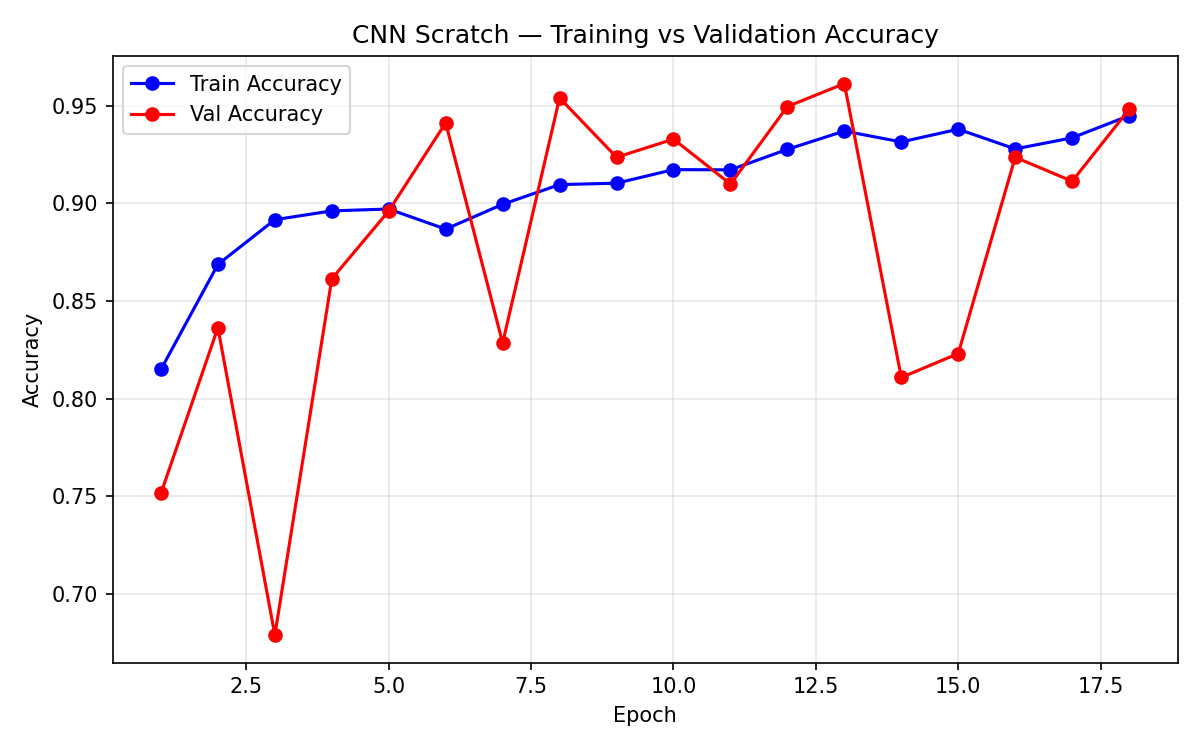

  CNN — Loss curve:


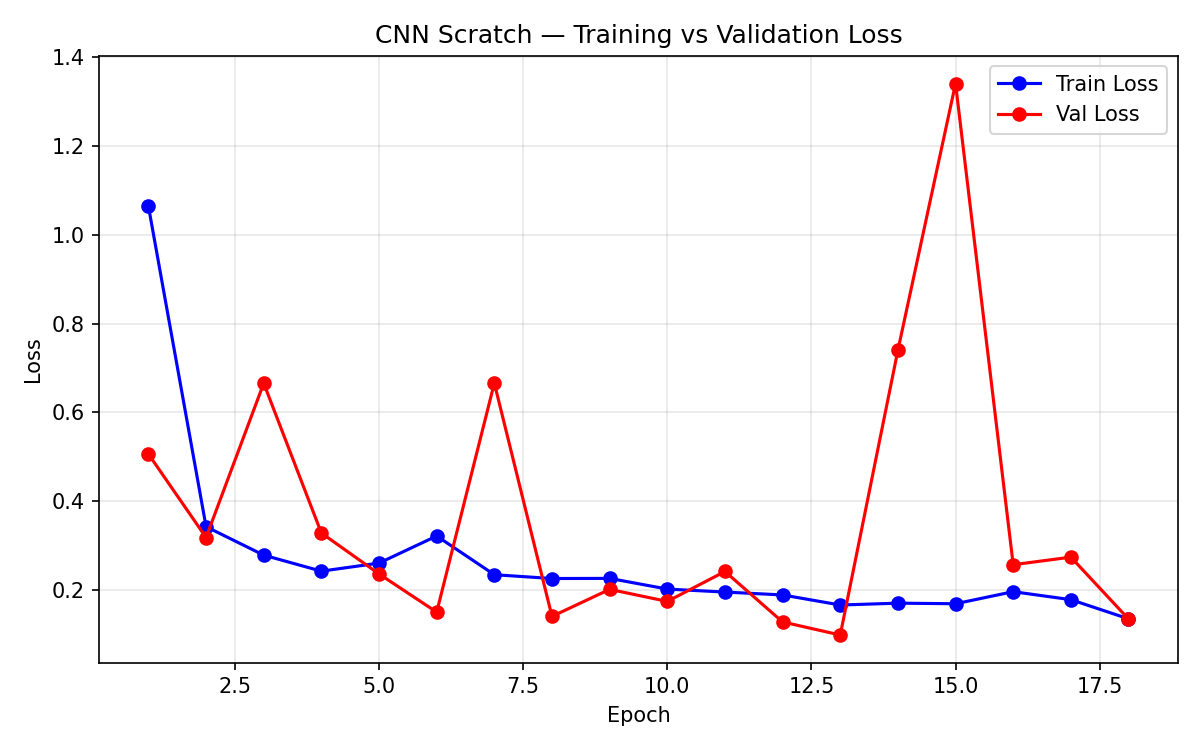

  Transfer MobileNetV2 — Accuracy curve:


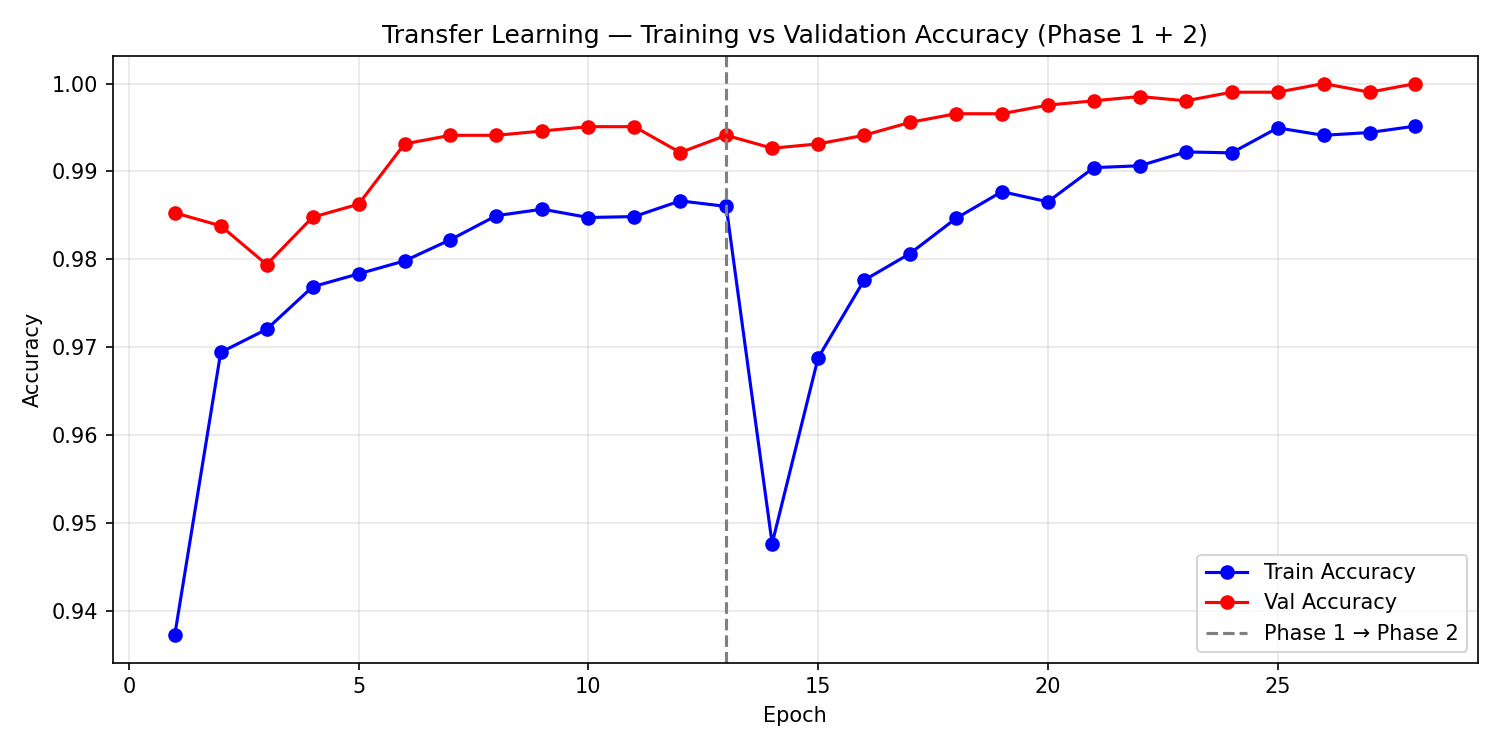

  Transfer MobileNetV2 — Loss curve:


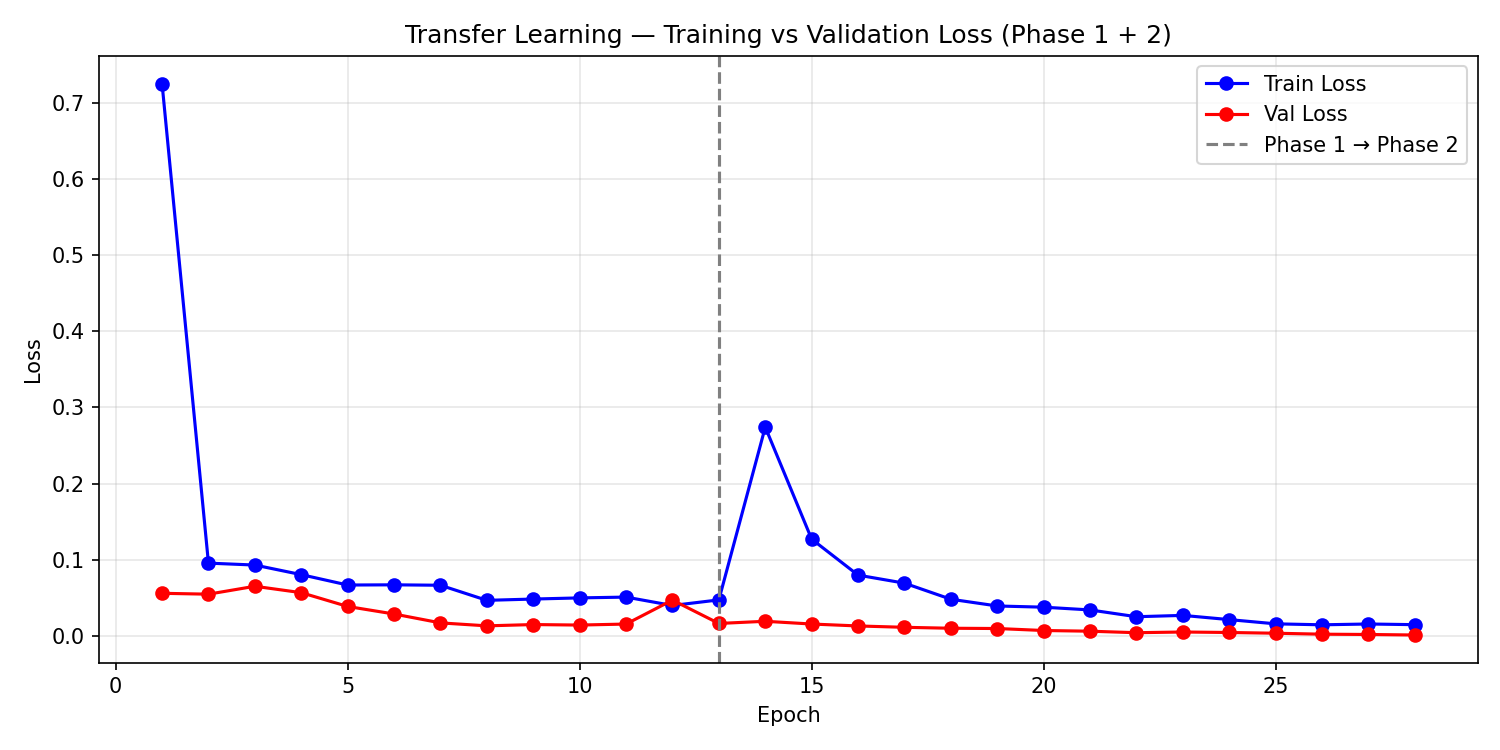


Evaluation complete!


In [9]:
from IPython.display import Image as IPImage, display

for name, suffix in [("CNN", "CNN"), ("Transfer MobileNetV2", "transfer")]:
    for metric in ["accuracy", "loss"]:
        path = os.path.join(PLOTS_DIR, f"{suffix}_{metric}.png")
        if os.path.exists(path):
            print(f"  {name} — {metric.capitalize()} curve:")
            display(IPImage(filename=path, width=600))
        else:
            print(f"  [WARN] Not found: {path}")

print("\nEvaluation complete!")
